---
title: Two fields — a spatial scale as well
subtitle: Letting the GEV scale σ(s) vary in space alongside the location μ(s)
short_title: Spatial μ and σ
authors:
  - name: Juan Emmanuel Johnson
date: 2026-06-05
keywords:
  - non-stationary extremes
  - Gaussian process
  - spatial scale
  - Laplace approximation
  - return levels
abstract: |
  Notebook 07 let the GEV location μ(s) roam as a Gaussian process while the
  scale σ and shape ξ stayed global. Here we give the **scale its own field**
  too: log σ(s) becomes a second, independent GP (plus nugget), so both where
  the distribution sits and how spread out it is may vary smoothly across Iberia.
  We fit the two-field model with the same fast Laplace approximation, map the
  new σ(s) surface, and ask the empirical question — does the scale actually
  carry spatial structure, and does freeing it change the 100-year levels? Only
  the shape ξ is still held global; notebook 09 frees that too.
---

# Two fields: a spatial location *and* a spatial scale

In notebook 07 only the GEV **location** moved in space,
$\mu(s) = \mu_0 + f(s) + \varepsilon_s$, while the **scale** $\sigma$ and
**shape** $\xi$ were single global numbers shared by every station. That is a
strong assumption: it says the spread of the annual maxima is identical in the
cool northern interior and on the warm Mediterranean coast, and only their
*centre* differs.

This notebook relaxes it one step. We give the scale its own Gaussian-process
field, on the **log** scale so it stays positive and varies multiplicatively:

$$
y_{s,t} \sim \mathrm{GEV}\big(\mu(s),\ \sigma(s),\ \xi\big), \qquad
\begin{aligned}
\mu(s) &= \mu_0 + f_\mu(s) + \varepsilon^\mu_s, \\
\log\sigma(s) &= \lambda_0 + f_\sigma(s) + \varepsilon^\sigma_s,
\end{aligned}
$$

with **two independent** GP fields
$f_\mu, f_\sigma \sim \mathcal{GP}\big(0, k_{3/2}\big)$ — each a Matérn-3/2 with a
fixed regional lengthscale and its own learned amplitude — and per-station
nuggets $\varepsilon^\mu_s, \varepsilon^\sigma_s$ absorbing local structure. The
shape $\xi$ stays **global**: it is the hardest parameter to identify (notebook
04), so we free it last, in notebook 09.

Everything else carries over from notebook 07: the whitened GP sampling, the
masked likelihood for the ragged records, and the Laplace-then-NUTS workflow.

In [1]:
import sys, pathlib
_p = pathlib.Path.cwd().resolve()
while not (_p / "src" / "spatial_extremes").exists():
    if _p == _p.parent:
        raise RuntimeError("Run from inside the spatial_extremes project")
    _p = _p.parent
if str(_p / "src") not in sys.path:
    sys.path.insert(0, str(_p / "src"))

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

In [3]:
import time

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import SVI, Trace_ELBO, Predictive, MCMC, NUTS
from numpyro.infer.autoguide import AutoLaplaceApproximation
from numpyro.infer.initialization import init_to_median

from pyrox.gp import GPPrior, Matern, gp_sample
from xtremax import GeneralizedExtremeValueDistribution as GEV
from xtremax import gev_return_level
from spatial_extremes import data
from spatial_extremes.viz import iberia_axes, scatter_field

maxima, stations, years, is_real = data.load_annual_maxima(min_years=20)
Y = jnp.asarray(maxima)                       # (S, T) — NaN where a year is missing
mask = ~jnp.isnan(Y)
S, T = Y.shape
lon, lat = stations[:, 0], stations[:, 1]
Xs = jnp.asarray(stations)
Xm, Xsd = Xs.mean(0), Xs.std(0)
Xn = (Xs - Xm) / Xsd                          # standardised coords for the kernel
ybar = jnp.asarray(np.nanmean(maxima, axis=1))
Y_MEAN = float(np.nanmean(maxima))
LENGTHSCALE = 0.8                             # fixed regional lengthscale (std units)
print("source:", "REAL" if is_real else "SYNTHETIC",
      "| stations", S, "| years", f"{years.min()}-{years.max()}", f"({T})")

source: REAL | stations 89 | years 1985-2025 (41)


## The two-field model

Each field is built the same way — a whitened Matérn-3/2 GP with a fixed regional
lengthscale and a learned variance, centred to remove the additive degeneracy
with its global offset — so a small helper keeps the model readable. The kernels
carry distinct `pyrox_name`s so their amplitude parameters don't collide.

The location field $f_\mu$ works in °C; the log-scale field $f_\sigma$ works in
**log** units, where a regional value of, say, $0.2$ means the scale is ~20%
larger than its neighbourhood baseline. Its prior amplitude is set
correspondingly small.

In [4]:
def gp_field(name, var_loc, Xn):
    """A centred, whitened Matérn-3/2 GP field with fixed lengthscale."""
    k = Matern(pyrox_name="k_" + name, nu=1.5, init_lengthscale=LENGTHSCALE)
    k.set_prior("variance", ndist.LogNormal(jnp.log(var_loc), 0.5))
    f = gp_sample("f_" + name, GPPrior(kernel=k, X=Xn), whitened=True)
    return f - jnp.mean(f)

def model(Xn, Y=None):
    f_mu = gp_field("mu", 4.0, Xn)            # location field (°C)
    f_ls = gp_field("ls", 0.1, Xn)            # log-scale field (log units)

    mu0 = numpyro.sample("mu0", ndist.Normal(Y_MEAN, 5.0))
    lam0 = numpyro.sample("lam0", ndist.Normal(jnp.log(2.0), 0.4))
    tau_mu = numpyro.sample("tau_mu", ndist.HalfNormal(2.0))      # location nugget
    tau_ls = numpyro.sample("tau_ls", ndist.HalfNormal(0.3))      # log-scale nugget
    xi_t = numpyro.sample("xi_t", ndist.Normal(0.0, 0.5))         # global shape
    with numpyro.plate("stations", S):
        z_mu = numpyro.sample("z_mu", ndist.Normal(0.0, 1.0))
        z_ls = numpyro.sample("z_ls", ndist.Normal(0.0, 1.0))

    mu_field = numpyro.deterministic("mu_field", mu0 + f_mu + tau_mu * z_mu)
    sigma_field = numpyro.deterministic(
        "sigma_field", jnp.exp(lam0 + f_ls + tau_ls * z_ls))
    xi = numpyro.deterministic("xi", 0.5 * jnp.tanh(xi_t))
    numpyro.deterministic("f_mu_s", f_mu)
    numpyro.deterministic("f_ls_s", f_ls)

    if Y is not None:
        yf = jnp.where(mask, Y, ybar[:, None])
        lp = GEV(loc=mu_field[:, None], scale=sigma_field[:, None],
                 concentration=xi).log_prob(yf)
        numpyro.factor("y", jnp.where(mask, lp, 0.0).sum())

## Fit with Laplace

Two latent fields plus their nuggets is a larger object than notebook 07, but the
geometry is no worse — the `AutoLaplaceApproximation` still optimises to the mode
in a few seconds. The ELBO loss should settle to a flat plateau.

Laplace fit in 4.2s · final ELBO loss 7324.3


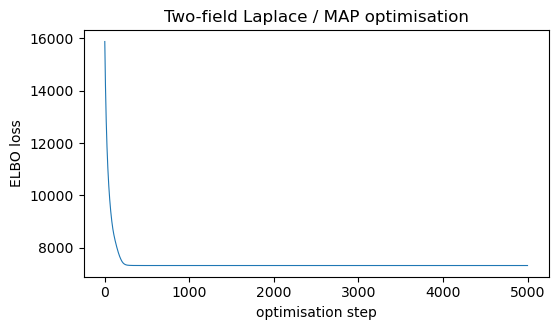

In [5]:
guide = AutoLaplaceApproximation(model, init_loc_fn=init_to_median)
opt = numpyro.optim.optax_to_numpyro(
    optax.chain(optax.zero_nans(), optax.clip_by_global_norm(10.0), optax.adam(3e-3))
)
svi = SVI(model, guide, opt, Trace_ELBO())
t0 = time.time()
res = svi.run(jr.PRNGKey(0), 5000, Xn, Y, progress_bar=False)
print(f"Laplace fit in {time.time() - t0:.1f}s · final ELBO loss "
      f"{float(res.losses[-1]):.1f}")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(np.asarray(res.losses), lw=0.8)
ax.set_xlabel("optimisation step")
ax.set_ylabel("ELBO loss")
ax.set_title("Two-field Laplace / MAP optimisation")
plt.show()

## Read off the posterior

As before, draw from the Laplace Gaussian and push the draws through `Predictive`
to recover the location and **scale** fields, their smooth components, and the
global tail.

In [6]:
lap = guide.sample_posterior(jr.PRNGKey(1), res.params, sample_shape=(600,))
pred = Predictive(model, posterior_samples=lap,
                  return_sites=["mu_field", "sigma_field", "f_mu_s", "f_ls_s", "xi"])
draws = pred(jr.PRNGKey(2), Xn)

mu_field = np.asarray(draws["mu_field"])      # (n, S)
sigma_field = np.asarray(draws["sigma_field"])
f_ls = np.asarray(draws["f_ls_s"])
xi = np.asarray(draws["xi"])
mu_med = mu_field.mean(0)
sig_med = sigma_field.mean(0)

print(f"global tail   ξ = {xi.mean():+.3f} ± {xi.std():.3f}")
print(f"location μ(s) range : {mu_med.min():.1f} -> {mu_med.max():.1f} °C")
print(f"scale    σ(s) range : {sig_med.min():.2f} -> {sig_med.max():.2f} °C "
      f"(global σ in nb 07 was ≈ 1.8)")
print(f"smooth log-σ field vs latitude: corr = "
      f"{np.corrcoef(f_ls.mean(0), lat)[0, 1]:+.2f}")

global tail   ξ = -0.219 ± 0.013
location μ(s) range : 28.2 -> 42.9 °C
scale    σ(s) range : 1.08 -> 3.79 °C (global σ in nb 07 was ≈ 1.8)
smooth log-σ field vs latitude: corr = -0.23


## The two surfaces

Location on the left, the **new** scale field on the right. Notebook 07 would have
shown the scale panel as a single flat colour; now it has texture.

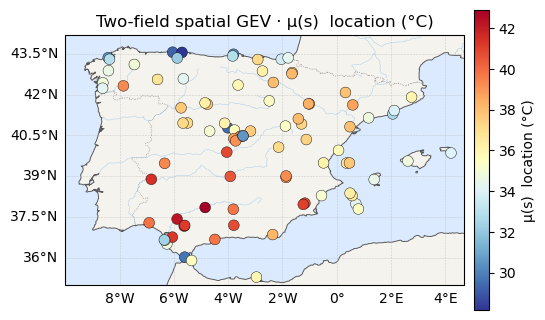

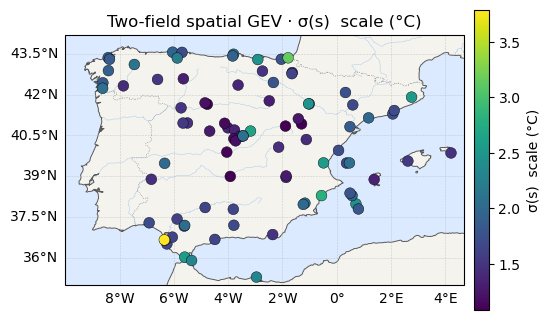

In [7]:
for vals, label, cmap in [(mu_med, "μ(s)  location (°C)", "RdYlBu_r"),
                          (sig_med, "σ(s)  scale (°C)", "viridis")]:
    ax = iberia_axes(figsize=(6.2, 5.2))
    scatter_field(ax, lon, lat, vals, label=label, cmap=cmap)
    ax.set_title(f"Two-field spatial GEV · {label}")
    plt.show()

## Is the scale really *spatial*?

A field can vary station-to-station without varying *smoothly* in space. Split
$\log\sigma(s)$ into its **regional** part (the GP $f_\sigma$) and its **local**
part (the nugget), and compare their spreads. If the regional part dominates, the
scale has genuine geography; if the nugget does, the scale wobbles locally
(elevation, exposure) more than it drifts across the peninsula — exactly the
pattern we saw for $\mu$.

log-σ regional (GP) SD : 0.087
log-σ local (nugget) SD: 0.204
=> the smooth field explains ~15% of the log-σ variation


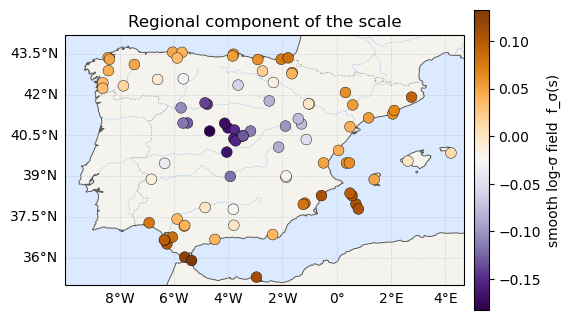

In [8]:
f_ls_med = f_ls.mean(0)                                   # smooth log-scale field
local = np.log(sig_med) - (np.log(sig_med).mean() + f_ls_med)  # nugget remainder
print(f"log-σ regional (GP) SD : {f_ls_med.std():.3f}")
print(f"log-σ local (nugget) SD: {local.std():.3f}")
share = f_ls_med.std()**2 / (f_ls_med.std()**2 + local.std()**2)
print(f"=> the smooth field explains ~{100 * share:.0f}% of the log-σ variation")

ax = iberia_axes(figsize=(6.2, 5.2))
scatter_field(ax, lon, lat, f_ls_med, label="smooth log-σ field  f_σ(s)",
              cmap="PuOr_r")
ax.set_title("Regional component of the scale")
plt.show()

## Return levels

The 100-year level now responds to a varying scale as well as a varying location.
We map the posterior-median $z_{100}$ and its 95% credible width, and compare the
average width with the single-field model.

z100 median range : 33.1 -> 47.6 °C
z100 95% CI width : 4.3 °C avg (max 9.1) [Laplace; nb 07 single-field was ≈ 2.7]


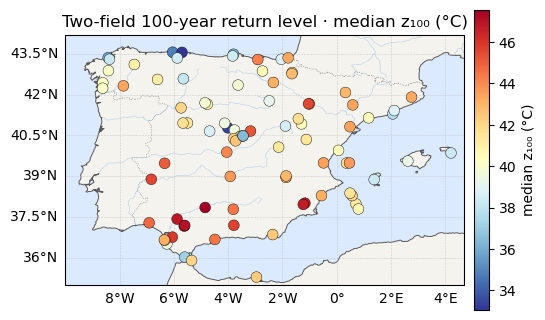

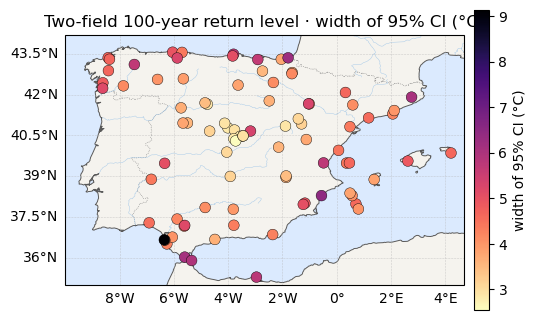

In [9]:
RL = np.asarray(gev_return_level(
    100.0, jnp.asarray(mu_field), jnp.asarray(sigma_field),
    jnp.asarray(xi)[:, None]))                # (n, S)
rl_med = np.median(RL, 0)
rl_ciw = np.quantile(RL, 0.975, 0) - np.quantile(RL, 0.025, 0)
print(f"z100 median range : {rl_med.min():.1f} -> {rl_med.max():.1f} °C")
print(f"z100 95% CI width : {rl_ciw.mean():.1f} °C avg (max {rl_ciw.max():.1f}) "
      f"[Laplace; nb 07 single-field was ≈ 2.7]")

for vals, label, cmap in [(rl_med, "median z₁₀₀ (°C)", "RdYlBu_r"),
                          (rl_ciw, "width of 95% CI (°C)", "magma_r")]:
    ax = iberia_axes(figsize=(6.2, 5.2))
    scatter_field(ax, lon, lat, vals, label=label, cmap=cmap)
    ax.set_title(f"Two-field 100-year return level · {label}")
    plt.show()

## A NUTS check

The same caveat as notebook 07 applies — Laplace nails the point estimates but
can mis-state interval *width*. A full NUTS run confirms the location and scale
fields and the global tail; we compare the per-station $z_{100}$ medians.

NUTS: 168s · 1 divergences
ξ:    Laplace -0.219±0.013   NUTS -0.215±0.011
z100 95% CI width:  Laplace 4.3 °C   NUTS 2.2 °C


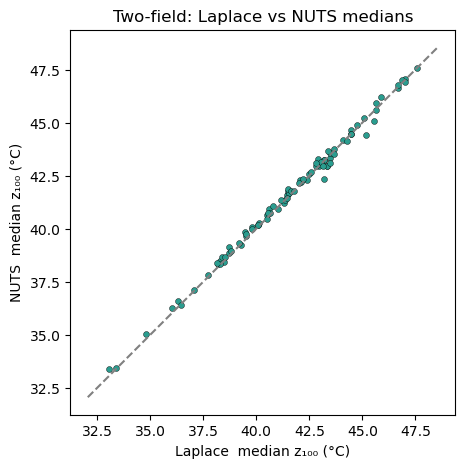

In [10]:
mcmc = MCMC(NUTS(model, init_strategy=init_to_median, target_accept_prob=0.95),
            num_warmup=800, num_samples=600, num_chains=1, progress_bar=False)
t0 = time.time()
mcmc.run(jr.PRNGKey(3), Xn, Y, extra_fields=("diverging",))
npost = mcmc.get_samples()
print(f"NUTS: {time.time() - t0:.0f}s · "
      f"{int(mcmc.get_extra_fields()['diverging'].sum())} divergences")

RL_n = np.asarray(gev_return_level(
    100.0, np.asarray(npost["mu_field"]), np.asarray(npost["sigma_field"]),
    np.asarray(npost["xi"])[:, None]))
rl_med_n = np.median(RL_n, 0)
print(f"ξ:    Laplace {xi.mean():+.3f}±{xi.std():.3f}   "
      f"NUTS {np.asarray(npost['xi']).mean():+.3f}±{np.asarray(npost['xi']).std():.3f}")
print(f"z100 95% CI width:  Laplace {rl_ciw.mean():.1f} °C   "
      f"NUTS {(np.quantile(RL_n, .975, 0) - np.quantile(RL_n, .025, 0)).mean():.1f} °C")

fig, ax = plt.subplots(figsize=(5.2, 5.0))
lo, hi = rl_med.min() - 1, rl_med.max() + 1
ax.plot([lo, hi], [lo, hi], ls="--", color="0.5")
ax.scatter(rl_med, rl_med_n, s=18, color="#2a9d8f", edgecolor="k", linewidth=0.3)
ax.set_xlabel("Laplace  median z₁₀₀ (°C)")
ax.set_ylabel("NUTS  median z₁₀₀ (°C)")
ax.set_title("Two-field: Laplace vs NUTS medians")
ax.set_aspect("equal")
plt.show()

## Takeaway

Freeing the scale costs almost nothing — a second whitened GP, the same
seconds-long Laplace fit — and answers a question the single-field model could
not even ask: *does the spread of the extremes vary across Iberia?* The printout
above quantifies how much of that variation is genuinely **regional** (the GP)
versus **local** (the nugget); as with $\mu$, the smooth share is modest, but the
$\sigma(s)$ map is no longer a flat constant, and the 100-year levels move with it.

One parameter is still global: the **shape** $\xi$. It is the tail exponent, the
hardest thing to pin down from a few decades of maxima — which is exactly why it
is interesting to set it free. **Next:** a third GP for $\xi(s)$, and an honest
look at whether spatial pooling can rescue a parameter that is barely identified
even in aggregate.